In [2]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

# HRDPS

In [3]:
hrdps = sorted(glob.glob('/results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2007m??d??.nc'))
print(len(hrdps))

363


In [4]:
combined = []
for file in hrdps:
    ds = xr.open_dataset(file)
    solar_data = ds["solar"]
    combined.append(solar_data.resample(time_counter="3h",label="left",closed="left",origin="start_day").mean())

xr.concat(combined, dim="time_counter").to_dataset(name="solar").to_netcdf("/home/dtaneja/analysis-dishika/notebooks/HRDPS_2007_solar.nc")

In [5]:
xr.concat(combined, dim="time_counter").shape

(2904, 266, 256)

In [6]:
ds_new = xr.open_dataset("/home/dtaneja/analysis-dishika/notebooks/HRDPS_2007_solar.nc")
print(ds_new)

<xarray.Dataset> Size: 791MB
Dimensions:       (time_counter: 2904, y: 266, x: 256)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 23kB 2007-01-03 ... 2007-12-3...
Dimensions without coordinates: y, x
Data variables:
    solar         (time_counter, y, x) float32 791MB ...


In [7]:
print(ds_new.time_counter.values[0])
print(ds_new.time_counter.values[-1])

2007-01-03T00:00:00.000000000
2007-12-31T21:00:00.000000000


In [8]:
solar = ds_new["solar"]
X_new = solar.values.reshape(2904, 266 * 256)
X_new.shape

(2904, 68096)

In [9]:
# Check missing values
np.isnan(X_new).sum()

np.int64(0)

In [10]:
pca_hrdps = PCA(n_components=2)
PCs_hrdps = pca_hrdps.fit_transform(X_new)
PCs_hrdps.shape

(2904, 2)

In [11]:
pca_hrdps.components_

array([[ 0.0040077 ,  0.00400668,  0.0040127 , ...,  0.00362554,
         0.00364674,  0.00364445],
       [ 0.00327539,  0.00326698,  0.00327572, ..., -0.00327956,
        -0.00335936, -0.00342428]], shape=(2, 68096), dtype=float32)

Text(0, 0.5, 'rlat')

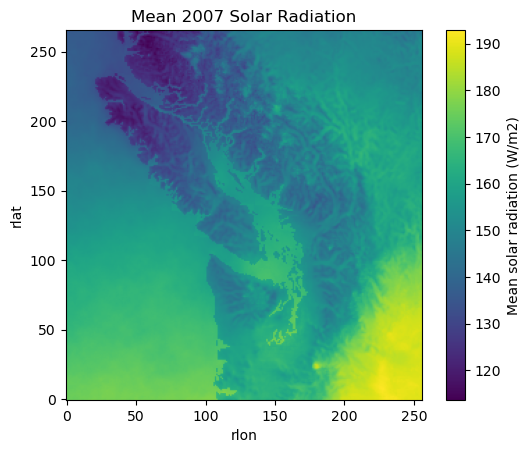

In [12]:
mean_2007 = pca_hrdps.mean_
mean_2007_map_hrdps = mean_2007.reshape(266, 256)
plt.imshow(mean_2007_map_hrdps, origin="lower")
plt.colorbar(label="Mean solar radiation (W/m2)")
plt.title("Mean 2007 Solar Radiation")
plt.xlabel("rlon")
plt.ylabel("rlat")

In [13]:
print(pca_hrdps.explained_variance_ratio_)
print(pca_hrdps.explained_variance_ratio_.sum())

[0.9017883  0.02422545]
0.92601377


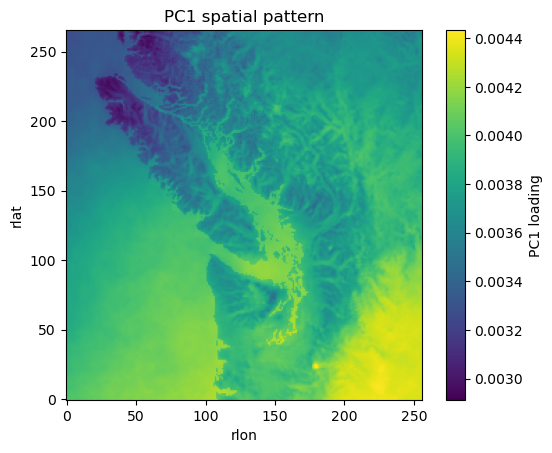

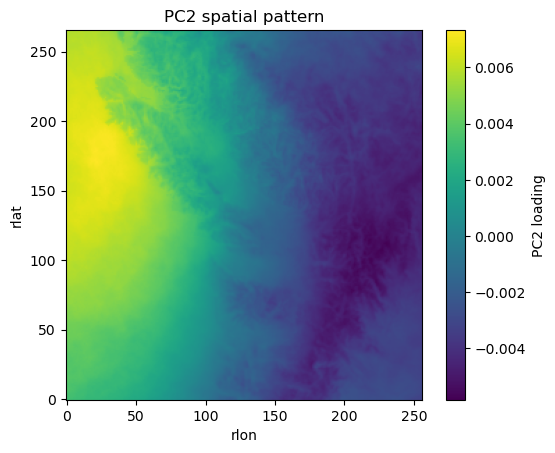

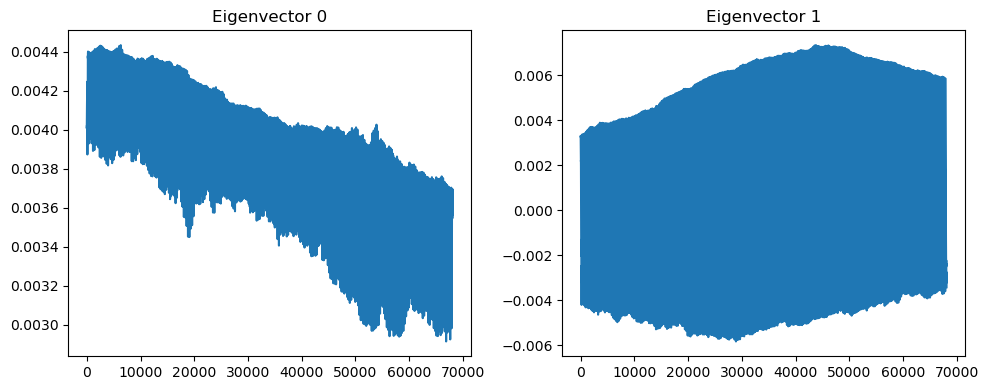

In [14]:
PC1_map_hrdps = pca_hrdps.components_[0].reshape(266, 256)
plt.imshow(PC1_map_hrdps, origin="lower")
plt.colorbar(label="PC1 loading")
plt.title("PC1 spatial pattern")
plt.xlabel("rlon")
plt.ylabel("rlat")
plt.show()

PC2_map_hrdps = pca_hrdps.components_[1].reshape(266, 256)
plt.imshow(PC2_map_hrdps, origin="lower")
plt.colorbar(label="PC2 loading")
plt.title("PC2 spatial pattern")
plt.xlabel("rlon")
plt.ylabel("rlat")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(pca_hrdps.components_[0])
axes[0].set_title("Eigenvector 0")
axes[1].plot(pca_hrdps.components_[1])
axes[1].set_title("Eigenvector 1")
plt.tight_layout()
plt.show()

# CanRCM5

In [15]:
files = sorted(glob.glob('/results/forcing/CanRCM5/*2007*.nc'))
for file in files:
    if "rsds" in xr.open_dataset(file).data_vars: #Solar Radiation
        ds = xr.open_dataset(file) 
        break

ds_2007 = ds.sel(time=slice("2007-01-03", "2007-12-31")) #Select data from January 2007
print(ds_2007)

# Solar Radiation data has shape: (time: 2904, rlat: 320, rlon: 360)
# This is 3 hourly solar radiation data for 2007

print(ds_2007["rsds"].shape)

print(ds_2007["rsds"].isel(time=0))

# Data is 2904 solar radiation maps, each of size 320x360 (latitude x longitude)


<xarray.Dataset> Size: 1GB
Dimensions:       (time: 2904, bnds: 2, rlat: 320, rlon: 360)
Coordinates:
  * time          (time) object 23kB 2007-01-03 00:00:00 ... 2007-12-31 21:00:00
  * rlat          (rlat) float64 3kB -35.11 -34.89 -34.67 ... 34.63 34.85 35.07
  * rlon          (rlon) float64 3kB -39.27 -39.05 -38.83 ... 39.27 39.49 39.71
    lon           (rlat, rlon) float64 922kB ...
    lat           (rlat, rlon) float64 922kB ...
Dimensions without coordinates: bnds
Data variables:
    time_bnds     (time, bnds) object 46kB ...
    rotated_pole  |S1 1B ...
    rsds          (time, rlat, rlon) float32 1GB ...
Attributes: (12/17)
    title:                          CanRCM4 model output prepared for CORDEX ...
    institution:                    CCCma (Canadian Centre for Climate Modell...
    institute_id:                   CCCma
    driving_experiment:             , , r1i1p1
    driving_model_ensemble_member:  r1i1p1
    realization:                    1
    ...                  

In [16]:
rsds = ds_2007["rsds"]

In [17]:
X = rsds.values.reshape(2904, 320 * 360) #Turns 3D array into 2D array of shape (2904, 115200) for PCA
X.shape

(2904, 115200)

In [18]:
np.isnan(X).sum()

np.int64(0)

In [19]:
X_mean = X.mean(axis=0)
X_centered = X - X_mean
print(X_centered.shape) 

(2904, 115200)


In [20]:
pca = PCA(n_components=2)
PCs = pca.fit_transform(X_centered)

In [21]:
pca.components_

array([[ 0.00385213,  0.00385321,  0.00385773, ...,  0.00026659,
         0.00025774,  0.00025048],
       [ 0.00525633,  0.00519978,  0.00517183, ..., -0.00376126,
        -0.00374826, -0.0037365 ]], shape=(2, 115200), dtype=float32)

[ 3.7411355e-05 -2.0427021e-04  7.5936645e-05 ...  1.7864974e-06
 -6.3404892e-05 -3.2622492e-04]


Text(0, 0.5, 'rlat')

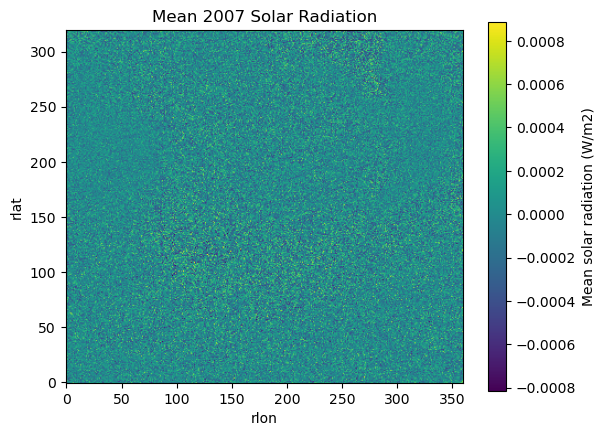

In [23]:
mean_2007 = pca.mean_
print(mean_2007)
mean_2007_map = mean_2007.reshape(320, 360)
plt.imshow(mean_2007_map, origin="lower")
plt.colorbar(label="Mean solar radiation (W/m2)")
plt.title("Mean 2007 Solar Radiation")
plt.xlabel("rlon")
plt.ylabel("rlat")

In [30]:
print(pca.explained_variance_ratio_)
print(pca.explained_variance_ratio_.sum())

[0.6229392  0.19369344]
0.8166327


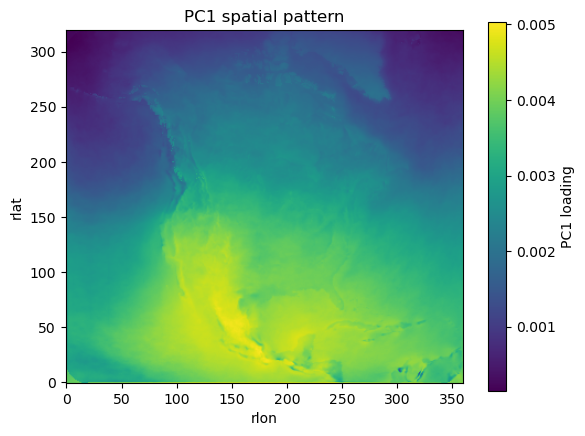

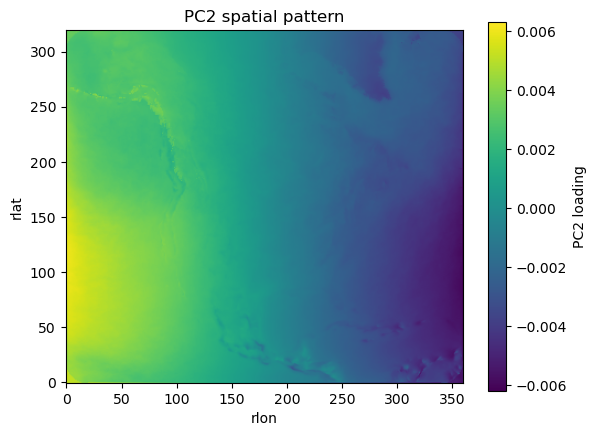

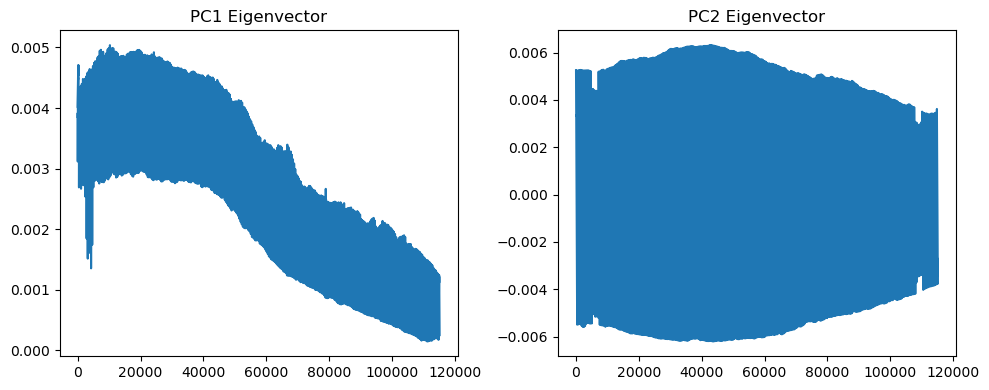

In [31]:
PC1_map = pca.components_[0].reshape(320, 360)
plt.imshow(PC1_map, origin="lower")
plt.colorbar(label="PC1 loading")
plt.title("PC1 spatial pattern")
plt.xlabel("rlon")
plt.ylabel("rlat")
plt.show()

PC2_map = pca.components_[1].reshape(320, 360)
plt.imshow(PC2_map, origin="lower")
plt.colorbar(label="PC2 loading")
plt.title("PC2 spatial pattern")
plt.xlabel("rlon")
plt.ylabel("rlat")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(pca.components_[0])
axes[0].set_title("PC1 Eigenvector")
axes[1].plot(pca.components_[1])
axes[1].set_title("PC2 Eigenvector")
plt.tight_layout()
plt.show()


# CanRCM5 Cutting to focus only on the area that is in HRDPS:

In [32]:
# Opening only the first file and extracting the latitude and longitude coordinates for the HRDPS data
ds0 = xr.open_dataset(hrdps[0])

lat_hr = ds0["nav_lat"]
lon_hr = ds0["nav_lon"]

In [33]:
ds_new = xr.open_dataset("/home/dtaneja/analysis-dishika/notebooks/HRDPS_2007_solar.nc")

# Adding the latitude and longitude coordinates to the new dataset
ds_new = ds_new.assign_coords(
    nav_lat=(("y", "x"), lat_hr.values),
    nav_lon=(("y", "x"), lon_hr.values)
)

ds_new.to_netcdf("/home/dtaneja/analysis-dishika/notebooks/HRDPS_2007_solar_with_latlon.nc")

# ds_new now contains solar, nav_lat, and nav_lon variables

In [34]:
print(ds_new.time_counter[0].values)
print(ds_new.time_counter[-1].values)
print(len(ds_new.time_counter))

2007-01-03T00:00:00.000000000
2007-12-31T21:00:00.000000000
2904


In [35]:
corners = { "bottom_left": (float(lat_hr.isel(y=0, x=0)),float(lon_hr.isel(y=0, x=0))),
           "bottom_right": (float(lat_hr.isel(y=0, x=-1)),float(lon_hr.isel(y=0, x=-1))),
           "top_left": (float(lat_hr.isel(y=-1, x=0)),float(lon_hr.isel(y=-1, x=0))),
           "top_right": (float(lat_hr.isel(y=-1, x=-1)),float(lon_hr.isel(y=-1, x=-1)))}

for name, (lat, lon) in corners.items():
    print("name:", name)
    print("lat:", lat)
    print("lon:", lon)

name: bottom_left
lat: 45.61257553100586
lon: 232.6595001220703
name: bottom_right
lat: 46.535892486572266
lon: 240.79672241210938
name: top_left
lat: 51.41788864135742
lon: 230.60208129882812
name: top_right
lat: 52.4603157043457
lon: 239.75860595703125


In [36]:
hr_lats = []
hr_lons = []
for coord in corners.values():
    hr_lats.append(coord[0])
    hr_lons.append(coord[1])

lat_min = min(hr_lats)
lat_max = max(hr_lats)
lon_min = min(hr_lons)
lon_max = max(hr_lons)

print(lat_min, lat_max)
print(lon_min, lon_max)

45.61257553100586 52.4603157043457
230.60208129882812 240.79672241210938


In [37]:
lat_lr = ds_2007["lat"]
lon_lr = ds_2007["lon"]

In [38]:
# Converts longitudes from 0-360 to -180 to 180
lon_lr = ((lon_lr + 180) % 360) - 180

In [39]:
# Converts longitudes from 0-360 to -180 to 180
lon_min = ((lon_min + 180) % 360) - 180
lon_max = ((lon_max + 180) % 360) - 180

In [40]:
# Create a mask to identify which CanRCM5 grid cells fall within the HRDPS region
mask_lr = (
    (lat_lr >= lat_min) & (lat_lr <= lat_max) &
    (lon_lr >= lon_min) & (lon_lr <= lon_max)
)

print("Number of CanRCM5 cells in HRDPS region:", int(mask_lr.sum()))

Number of CanRCM5 cells in HRDPS region: 947


In [41]:
i_idx, j_idx = np.where(mask_lr.values) # Finds array indices where mask_lr is True

i_min, i_max = i_idx.min(), i_idx.max()
j_min, j_max = j_idx.min(), j_idx.max()

print(i_min, i_max, j_min, j_max) # These indices can be used to subset the CanRCM5 data to the HRDPS region for further analysis

162 200 79 117


In [42]:
ds_2007_cut = ds_2007.isel(rlat=slice(i_min, i_max + 1),rlon=slice(j_min, j_max + 1))

print(ds_2007_cut)
print(ds_2007_cut["rsds"].shape)

<xarray.Dataset> Size: 18MB
Dimensions:       (time: 2904, bnds: 2, rlat: 39, rlon: 39)
Coordinates:
  * time          (time) object 23kB 2007-01-03 00:00:00 ... 2007-12-31 21:00:00
  * rlat          (rlat) float64 312B 0.53 0.75 0.97 1.19 ... 8.45 8.67 8.89
  * rlon          (rlon) float64 312B -21.89 -21.67 -21.45 ... -13.75 -13.53
    lon           (rlat, rlon) float64 12kB 232.0 232.3 232.5 ... 239.3 239.6
    lat           (rlat, rlon) float64 12kB 43.66 43.74 43.82 ... 54.29 54.35
Dimensions without coordinates: bnds
Data variables:
    time_bnds     (time, bnds) object 46kB ...
    rotated_pole  |S1 1B ...
    rsds          (time, rlat, rlon) float32 18MB 57.0 56.04 ... 117.7 173.8
Attributes: (12/17)
    title:                          CanRCM4 model output prepared for CORDEX ...
    institution:                    CCCma (Canadian Centre for Climate Modell...
    institute_id:                   CCCma
    driving_experiment:             , , r1i1p1
    driving_model_ensemble_memb

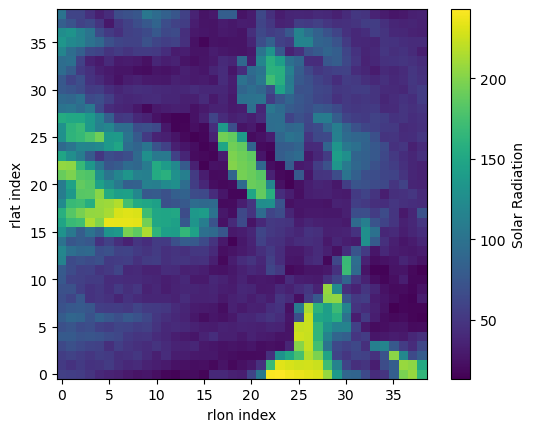

In [43]:
rsds_cut = ds_2007_cut["rsds"]
plt.imshow(rsds_cut.isel(time=0), origin="lower")
plt.colorbar(label="Solar Radiation")
plt.xlabel("rlon index")
plt.ylabel("rlat index")
plt.show()

In [45]:
n_time = rsds_cut.sizes["time"]
n_rlat = rsds_cut.sizes["rlat"]
n_rlon = rsds_cut.sizes["rlon"]

X_cut = rsds_cut.values.reshape(n_time, n_rlat * n_rlon)

print(X_cut.shape)

(2904, 1521)


In [46]:
X_mean_cut = X_cut.mean(axis=0)
X_centered_cut = X_cut - X_mean_cut
print(X_centered_cut.shape) 

(2904, 1521)


In [47]:
pca_cut = PCA(n_components=2)
PCs_cut = pca_cut.fit_transform(X_centered_cut)

print(pca_cut.explained_variance_ratio_)
print(pca_cut.explained_variance_ratio_.sum())

[0.8571439  0.03093705]
0.88808095


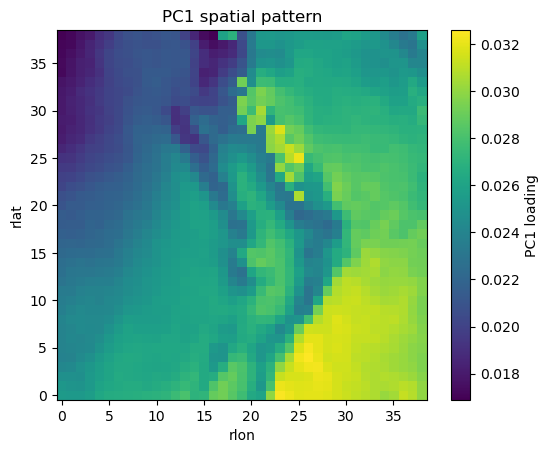

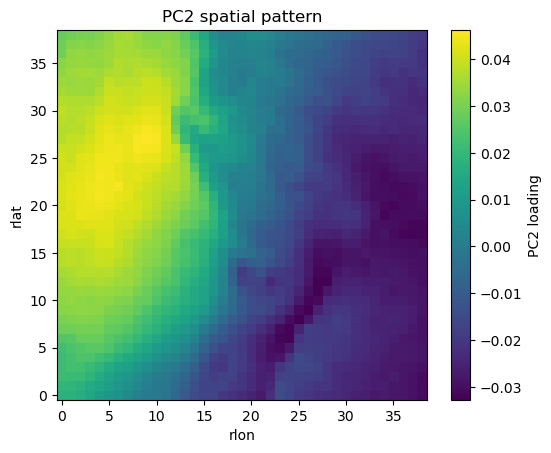

In [48]:
PC1_cut_map = pca_cut.components_[0].reshape(n_rlat, n_rlon)
plt.imshow(PC1_cut_map, origin="lower")
plt.colorbar(label="PC1 loading")
plt.title("PC1 spatial pattern")
plt.xlabel("rlon")
plt.ylabel("rlat")
plt.show()

PC2_cut_map = pca_cut.components_[1].reshape(n_rlat, n_rlon)
plt.imshow(PC2_cut_map, origin="lower")
plt.colorbar(label="PC2 loading")
plt.title("PC2 spatial pattern")
plt.xlabel("rlon")
plt.ylabel("rlat")
plt.show()

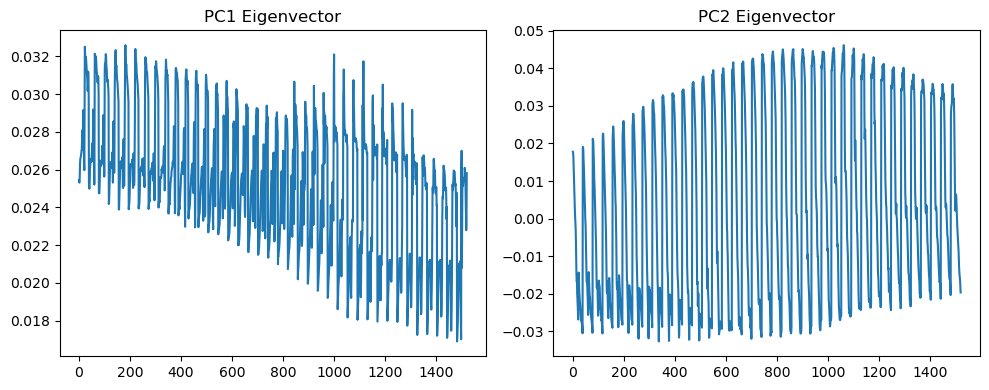

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(pca_cut.components_[0])
axes[0].set_title("PC1 Eigenvector")
axes[1].plot(pca_cut.components_[1])
axes[1].set_title("PC2 Eigenvector")
plt.tight_layout()
plt.show()

# Checking Correlation

In [50]:
lr_scores = PCs_cut[:, :2]   
hr_scores = PCs_hrdps[:, :2] 

corr_matrix = np.zeros((2, 2))

for i in range(2):
    for j in range(2):
        corr_matrix[i, j] = np.corrcoef(lr_scores[:, i], hr_scores[:, j])[0, 1]

corr_df = pd.DataFrame(
    corr_matrix,
    index=["CanRCM_PC1", "CanRCM_PC2"],
    columns=["HRDPS_PC1", "HRDPS_PC2"]
)

print(corr_df)

            HRDPS_PC1  HRDPS_PC2
CanRCM_PC1   0.798796   0.157536
CanRCM_PC2  -0.248708   0.593224


In [51]:
abs_corr_df = corr_df.abs()
print(abs_corr_df)

            HRDPS_PC1  HRDPS_PC2
CanRCM_PC1   0.798796   0.157536
CanRCM_PC2   0.248708   0.593224


In [52]:
print(ds_2007_cut.time.values[:10])
print(ds_new.time_counter.values[:10])

print(ds_2007_cut.time.values[-10:])
print(ds_new.time_counter.values[-10:])

[cftime.DatetimeNoLeap(2007, 1, 3, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2007, 1, 3, 3, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2007, 1, 3, 6, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2007, 1, 3, 9, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2007, 1, 3, 12, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2007, 1, 3, 15, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2007, 1, 3, 18, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2007, 1, 3, 21, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2007, 1, 4, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2007, 1, 4, 3, 0, 0, 0, has_year_zero=True)]
['2007-01-03T00:00:00.000000000' '2007-01-03T03:00:00.000000000'
 '2007-01-03T06:00:00.000000000' '2007-01-03T09:00:00.000000000'
 '2007-01-03T12:00:00.000000000' '2007-01-03T15:00:00.000000000'
 '2007-01-03T18:00:00.000000000' '2007-01-03T21:00:00.000000000'
 '2007-01-04T00:00:00.000000000' '2007-01-04T03:00:00.000000000']

In [53]:
pc_df = pd.DataFrame({
    "CanRCM_PC1": lr_scores[:, 0],
    "CanRCM_PC2": lr_scores[:, 1],
    "HRDPS_PC1": hr_scores[:, 0],
    "HRDPS_PC2": hr_scores[:, 1]
})

pairs = [("CanRCM_PC1", "HRDPS_PC1"),("CanRCM_PC2", "HRDPS_PC2")]

for lr_name, hr_name in pairs:
    print(lr_name, hr_name)
    for lag in range(-3, 4):
        corr = pc_df[lr_name].corr(pc_df[hr_name].shift(lag))
        print("Lag",lag,":",corr)

CanRCM_PC1 HRDPS_PC1
Lag -3 : -0.422440252738013
Lag -2 : -0.22306087606110778
Lag -1 : 0.24716163505655642
Lag 0 : 0.7987959304706683
Lag 1 : 0.9710229945151745
Lag 2 : 0.5792819038530174
Lag 3 : 0.007818680910614025
CanRCM_PC2 HRDPS_PC2
Lag -3 : -0.023628800848097233
Lag -2 : 0.03106126673154875
Lag -1 : 0.2595638352114881
Lag 0 : 0.5932243096817775
Lag 1 : 0.6637508276580377
Lag 2 : 0.3635955265868263
Lag 3 : 0.07406286289225111


In [54]:
lr_scores = PCs_cut[:, :2]   
hr_scores = PCs_hrdps[:, :2] 

In [56]:
time = pd.to_datetime([str(t) for t in ds_2007_cut.time.values])


In [57]:
pc_df = pd.DataFrame({
    "time": time,
    "CanRCM_PC1": lr_scores[:, 0],
    "CanRCM_PC2": lr_scores[:, 1],
    "HRDPS_PC1": hr_scores[:, 0],
    "HRDPS_PC2": hr_scores[:, 1]
})

In [58]:
train_df = pc_df[pc_df["time"] < "2007-10-01"]
test_df = pc_df[pc_df["time"] >= "2007-10-01"]
# Training 9 months and Testing 3 months

In [59]:
X_train = train_df[["CanRCM_PC1", "CanRCM_PC2"]].values
X_test = test_df[["CanRCM_PC1", "CanRCM_PC2"]].values
Y_train = train_df[["HRDPS_PC1", "HRDPS_PC2"]].values
Y_test = test_df[["HRDPS_PC1", "HRDPS_PC2"]].values

In [60]:
mlr = LinearRegression()
mlr.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [61]:
mlr.coef_

array([[ 5.9507623 , -9.948502  ],
       [ 0.20298098,  3.9260702 ]], dtype=float32)

In [62]:
mlr.intercept_

array([1556.3442, -138.8042], dtype=float32)

In [63]:
Y_pred = mlr.predict(X_test)

In [64]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

mse = mean_squared_error(Y_test, Y_pred)
mae = mean_absolute_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)
adj_r2 = 1 - (1 - r2) * (len(Y_test) - 1) / (len(Y_test) - 2 - 1)

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R-squared:", r2)
print("Adjusted R-squared:", adj_r2)

Mean Squared Error: 213704976.0
Mean Absolute Error: 8653.90234375
R-squared: 0.3213270306587219
Adjusted R-squared: 0.31947526266597626


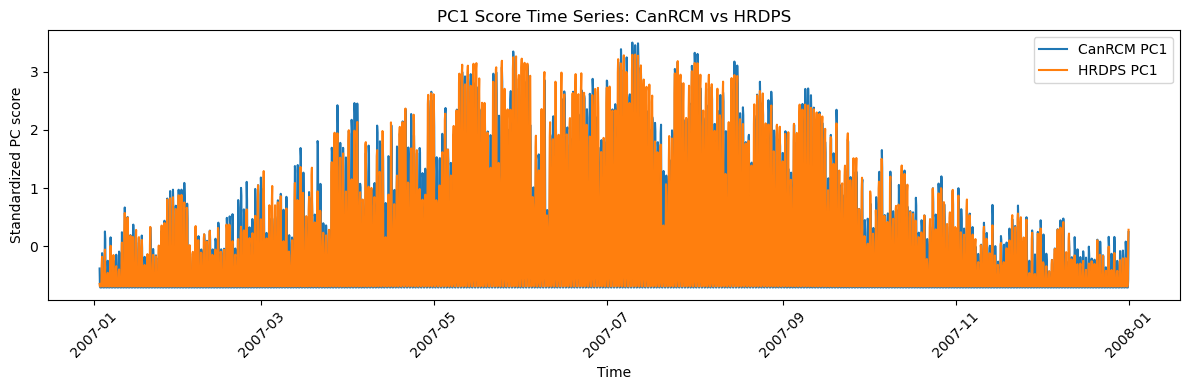

In [65]:
pc_df["CanRCM_PC1_std"] = (pc_df["CanRCM_PC1"] - pc_df["CanRCM_PC1"].mean()) / pc_df["CanRCM_PC1"].std()
pc_df["HRDPS_PC1_std"] = (pc_df["HRDPS_PC1"] - pc_df["HRDPS_PC1"].mean()) / pc_df["HRDPS_PC1"].std()

plt.figure(figsize=(12, 4))
plt.plot(pc_df["time"], pc_df["CanRCM_PC1_std"], label="CanRCM PC1")
plt.plot(pc_df["time"], pc_df["HRDPS_PC1_std"], label="HRDPS PC1")
plt.title("PC1 Score Time Series: CanRCM vs HRDPS")
plt.xlabel("Time")
plt.ylabel("Standardized PC score")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

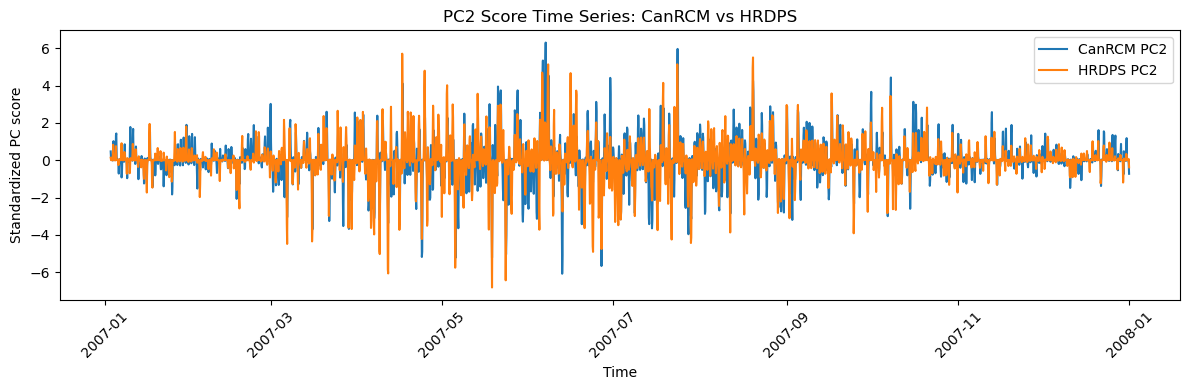

In [66]:
pc_df["CanRCM_PC2_std"] = (pc_df["CanRCM_PC2"] - pc_df["CanRCM_PC2"].mean()) / pc_df["CanRCM_PC2"].std()
pc_df["HRDPS_PC2_std"] = (pc_df["HRDPS_PC2"] - pc_df["HRDPS_PC2"].mean()) / pc_df["HRDPS_PC2"].std()

plt.figure(figsize=(12, 4))
plt.plot(pc_df["time"], pc_df["CanRCM_PC2_std"], label="CanRCM PC2")
plt.plot(pc_df["time"], pc_df["HRDPS_PC2_std"], label="HRDPS PC2")
plt.title("PC2 Score Time Series: CanRCM vs HRDPS")
plt.xlabel("Time")
plt.ylabel("Standardized PC score")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()